<a href="https://colab.research.google.com/github/monasolgi/Computer_vision/blob/main/tutorial1_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving images.zip to images.zip


In [5]:
import zipfile

with zipfile.ZipFile("images.zip", 'r') as zip_ref:
    zip_ref.extractall("images")

In [6]:
import os
print(os.listdir("images"))

['images']


In [7]:
import tensorflow as tf

train = tf.keras.utils.image_dataset_from_directory(
    "images/images/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

val = tf.keras.utils.image_dataset_from_directory(
    "images/images/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

test = tf.keras.utils.image_dataset_from_directory(
    "images/images/test",
    image_size=(224,224),
    batch_size=32
)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(2, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(train, validation_data=val, epochs=10)
model.evaluate(test)

Found 160 files belonging to 2 classes.
Using 128 files for training.
Found 160 files belonging to 2 classes.
Using 32 files for validation.
Found 40 files belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6719 - loss: 0.6371 - val_accuracy: 0.7812 - val_loss: 0.4963
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8281 - loss: 0.3877 - val_accuracy: 0.8750 - val_loss: 0.3072
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.8906 - loss: 0.2698 - val_accuracy: 0.9375 - val_loss: 0.2101
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9141 - loss: 0.2061 - val_accuracy: 1.0000 - val_loss: 0.1513
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9609 - loss: 0.1598 - val_accuracy: 1.0000 - val_loss: 0.1174
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9609 - loss: 0.1279 - val_accuracy: 1.0000 - val_loss: 0.0978
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━

[0.05507085472345352, 1.0]

In [8]:
print(train.class_names)

['class1', 'class2']


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


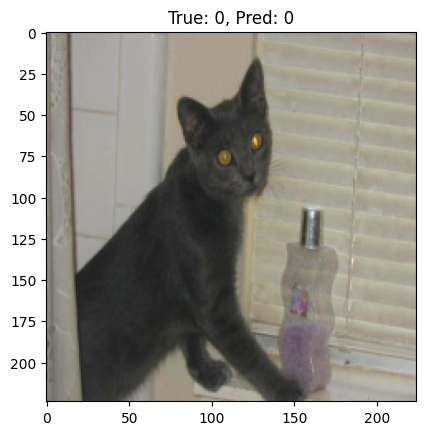

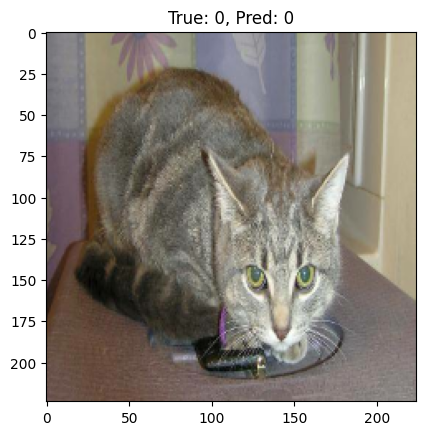

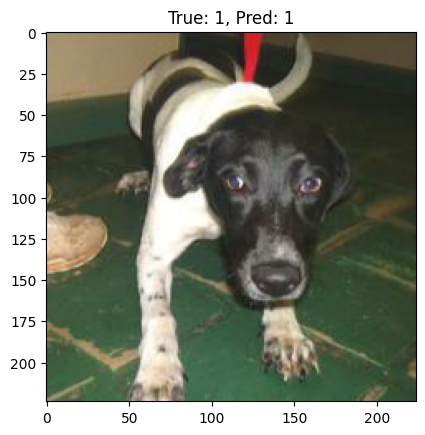

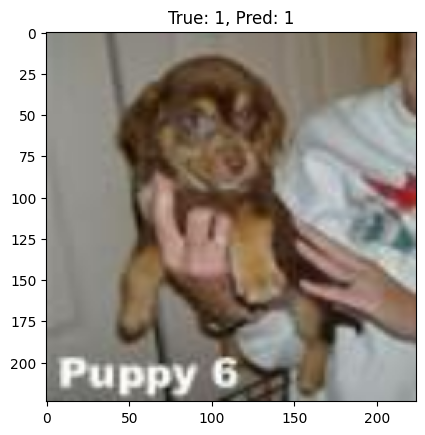

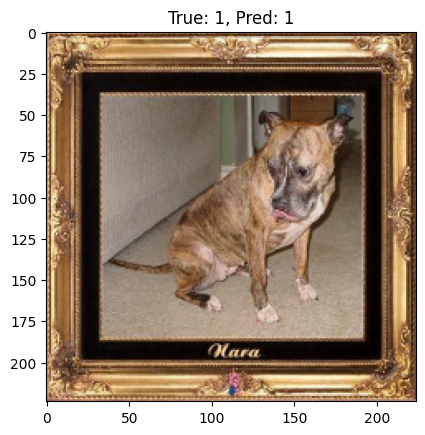

In [9]:
import matplotlib.pyplot as plt

for images, labels in test.take(1):
    preds = model.predict(images)
    for i in range(5):
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {labels[i].numpy()}, Pred: {preds[i].argmax()}")
        plt.show()